# Notebook 15 — Network Diagnostics and Visualisation

Diagnostic checks on the four network layers (arms transfers, bilateral ODA,
econ neo-colonial score, colonial tie) before any modelling.
All outputs inform the hub-and-spoke and multiplex-structure assessment.

**Inputs:**
- `../data/merged/network_measures_1992_2024.csv` — monadic centrality measures (pre-lagged)
- `../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv` — dyadic edge-level panel

**Outputs:**
- `../outputs/limitations/network_degree_distributions.png`
- `../outputs/limitations/network_density_over_time.png`
- `../outputs/limitations/network_layer_overlap.png`
- `../outputs/limitations/network_centrality_variance.png`
- `../outputs/results/network_top_nodes.png`
- `../outputs/results/key_countries_network_trajectories.png`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- Style constants ---------------------------------------------------
BG = '#F5F2EE'
LAYERS = ['arms_tiv', 'bilateral_oda', 'econ_neocol_score', 'colonial_tie']
LAYER_COLORS = {
    'arms_tiv':          '#8B5E3C',
    'bilateral_oda':     '#4A7C6F',
    'econ_neocol_score': '#5B7DB1',
    'colonial_tie':      '#C17A4A',
}
LAYER_LABELS = {
    'arms_tiv':          'Arms Transfers',
    'bilateral_oda':     'Bilateral ODA',
    'econ_neocol_score': 'Econ Neo-Colonial Score',
    'colonial_tie':      'Colonial Tie',
}

mpl.rcParams.update({
    'font.family':        'sans-serif',
    'axes.facecolor':     BG,
    'figure.facecolor':   BG,
    'axes.grid':          False,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

# --- Output directories ------------------------------------------------
out_lim = Path('../../outputs/limitations')
out_res = Path('../../outputs/results')
out_lim.mkdir(parents=True, exist_ok=True)
out_res.mkdir(parents=True, exist_ok=True)

# --- Shared helpers ----------------------------------------------------
def edge_mask(df, layer):
    """Boolean mask for rows where the given layer has an active edge."""
    if layer == 'colonial_tie':
        return df['colonial_tie'] == 1
    return df[layer].fillna(0) > 0

def gini_coeff(arr):
    """Gini coefficient over positive finite values."""
    arr = np.array(arr, dtype=float)
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if len(arr) == 0:
        return np.nan
    arr = np.sort(arr)
    n = len(arr)
    idx = np.arange(1, n + 1)
    return (2.0 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1.0) / n

print('Setup complete.')


Setup complete.


In [2]:
nm = pd.read_csv('../../data/merged/network_measures_1992_2024.csv')
dp = pd.read_csv('../../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv')

print(f'Network measures : {nm.shape[0]:,} rows × {nm.shape[1]} cols')
print(f'Dyadic panel     : {dp.shape[0]:,} rows × {dp.shape[1]} cols')
print(f'Year range       : {dp["year"].min()} – {dp["year"].max()}')
print(f'Unique senders   : {dp["sender_iso3"].nunique()}')
print(f'Unique recipients: {dp["recipient_iso3"].nunique()}')
print()
print('Dyadic panel columns:', dp.columns.tolist())
print('\nNetwork measures columns:', nm.columns.tolist())

# Quick missingness snapshot per layer column
print('\nLayer column non-null counts in dyadic panel:')
for layer in LAYERS:
    n_vals = dp[layer].notna().sum()
    n_pos  = (dp[layer].fillna(0) > 0).sum()
    print(f'  {LAYER_LABELS[layer]:35s}: {n_vals:,} non-null  |  {n_pos:,} positive edges')


Network measures : 6,526 rows × 22 cols
Dyadic panel     : 115,640 rows × 15 cols
Year range       : 1992 – 2024
Unique senders   : 112
Unique recipients: 213

Dyadic panel columns: ['sender_iso3', 'recipient_iso3', 'year', 'arms_tiv', 'bilateral_oda', 'econ_neocol_score', 'colonial_tie', 'journalist_killings', 'gdp_per_capita', 'gdp_per_capita_log', 'population', 'population_log', 'armed_conflict', 'conflict_intensity', 'econ_neocol_score_log']

Network measures columns: ['recipient_iso3', 'year', 'arms_tiv_in_strength_lag1', 'arms_tiv_out_strength_lag1', 'arms_tiv_dependency_balance_lag1', 'arms_tiv_in_concentration_lag1', 'arms_tiv_pagerank_lag1', 'bilateral_oda_in_strength_lag1', 'bilateral_oda_out_strength_lag1', 'bilateral_oda_dependency_balance_lag1', 'bilateral_oda_in_concentration_lag1', 'bilateral_oda_pagerank_lag1', 'colonial_tie_in_strength_lag1', 'colonial_tie_out_strength_lag1', 'colonial_tie_dependency_balance_lag1', 'colonial_tie_in_concentration_lag1', 'colonial_tie_pa

## Part 1 — Degree Distributions per Layer

For each layer, compute mean in-degree per country (averaged across years).
Also compute the Gini coefficient on total in-strength as a summary of inequality.

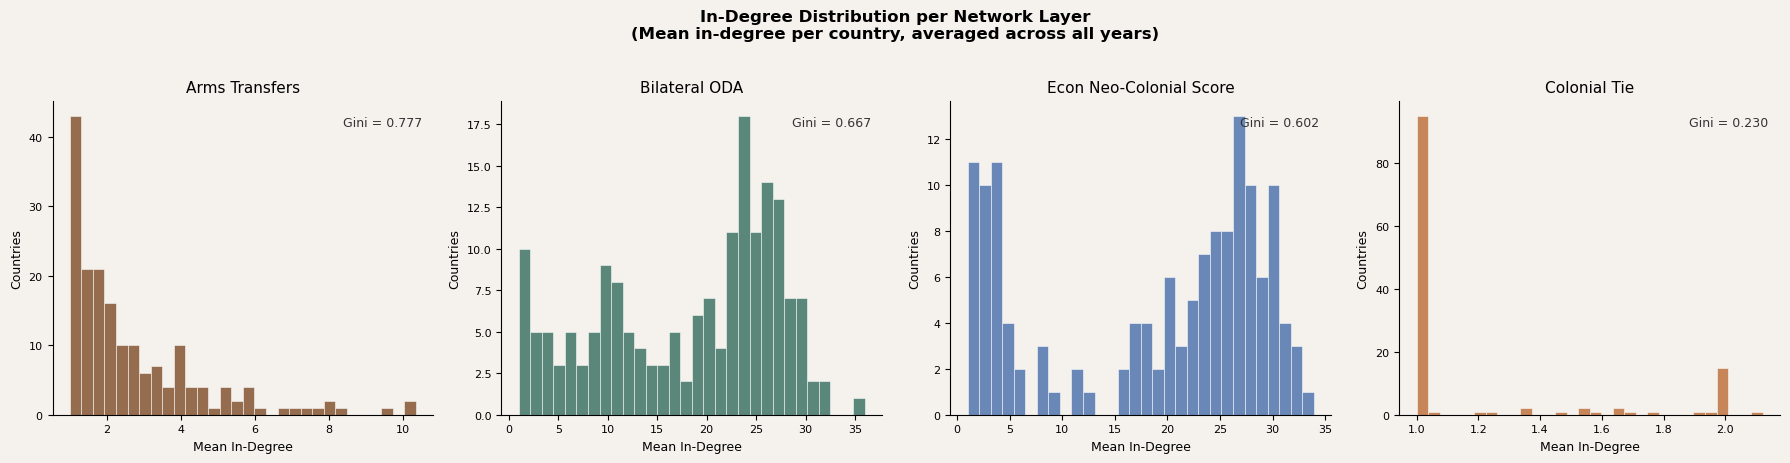

Saved: outputs/limitations/network_degree_distributions.png

--- Gini Coefficients on In-Strength (all years combined) ---
  Arms Transfers                     : Gini = 0.777  → heavy-tailed  → few dominant hub recipients
  Bilateral ODA                      : Gini = 0.667  → heavy-tailed  → few dominant hub recipients
  Econ Neo-Colonial Score            : Gini = 0.602  → heavy-tailed  → few dominant hub recipients
  Colonial Tie                       : Gini = 0.230  → relatively uniform distribution


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), facecolor=BG)
fig.suptitle(
    'In-Degree Distribution per Network Layer\n'
    '(Mean in-degree per country, averaged across all years)',
    fontsize=12, fontweight='bold', y=1.02
)

for ax, layer in zip(axes, LAYERS):
    mask = edge_mask(dp, layer)

    # in-degree: distinct senders per (recipient, year)
    in_deg_yr = (
        dp[mask]
        .groupby(['recipient_iso3', 'year'])['sender_iso3']
        .count()
    )
    mean_in_deg = in_deg_yr.groupby('recipient_iso3').mean()

    # in-strength: sum of edge weights per recipient (all years)
    in_str = dp[mask].groupby('recipient_iso3')[layer].sum()
    g = gini_coeff(in_str.values)

    ax.set_facecolor(BG)
    ax.hist(
        mean_in_deg.values, bins=30,
        color=LAYER_COLORS[layer], edgecolor='white', linewidth=0.4, alpha=0.9
    )
    ax.set_title(LAYER_LABELS[layer], fontsize=11, pad=6)
    ax.set_xlabel('Mean In-Degree', fontsize=9)
    ax.set_ylabel('Countries', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.text(
        0.97, 0.95, f'Gini = {g:.3f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='#333333'
    )

plt.tight_layout()
plt.savefig(out_lim / 'network_degree_distributions.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: outputs/limitations/network_degree_distributions.png')

# --- Print interpretation -----------------------------------------------
print('\n--- Gini Coefficients on In-Strength (all years combined) ---')
for layer in LAYERS:
    mask = edge_mask(dp, layer)
    in_str = dp[mask].groupby('recipient_iso3')[layer].sum()
    g = gini_coeff(in_str.values)
    tail = (
        'heavy-tailed  → few dominant hub recipients'
        if g > 0.6 else
        'relatively uniform distribution'
    )
    print(f'  {LAYER_LABELS[layer]:35s}: Gini = {g:.3f}  → {tail}')


## Part 2 — Top Senders and Recipients per Layer

Aggregated across all years 1992–2024. Out-strength = total weight sent;
in-strength = total weight received.


Arms Transfers
  Top 10 Senders (out-strength):
    USA: 324549.1200
    RUS: 157140.7200
    FRA: 63190.1400
    DEU: 55845.3800
    GBR: 39342.8400
    CHN: 36732.4100
    ITA: 21097.1300
    ISR: 18865.6300
    NLD: 16465.3100
    ESP: 15423.5000
  Top 10 Recipients (in-strength):
    IND: 70890.3200
    SAU: 51803.2000
    CHN: 48338.2700
    KOR: 35769.8500
    TUR: 30954.6800
    EGY: 30954.0000
    PAK: 28214.7700
    ARE: 27282.0900
    JPN: 27172.1900
    AUS: 26263.4000

Bilateral ODA
  Top 10 Senders (out-strength):
    USA: 486924.5331
    JPN: 257671.2841
    DEU: 199058.9428
    FRA: 164419.5939
    GBR: 131417.9208
    TUR: 77970.3287
    CAN: 54301.2676
    ARE: 51521.5205
    AUS: 50002.6109
    NLD: 45151.5083
  Top 10 Recipients (in-strength):
    SYR: 95380.1354
    IRQ: 86638.8787
    AFG: 78398.5239
    UKR: 62582.7775
    IND: 55930.8140
    EGY: 50004.3957
    ETH: 47858.1416
    BGD: 44332.9663
    NGA: 40589.6848
    IDN: 40440.2248

Econ Neo-Colonial Score
 

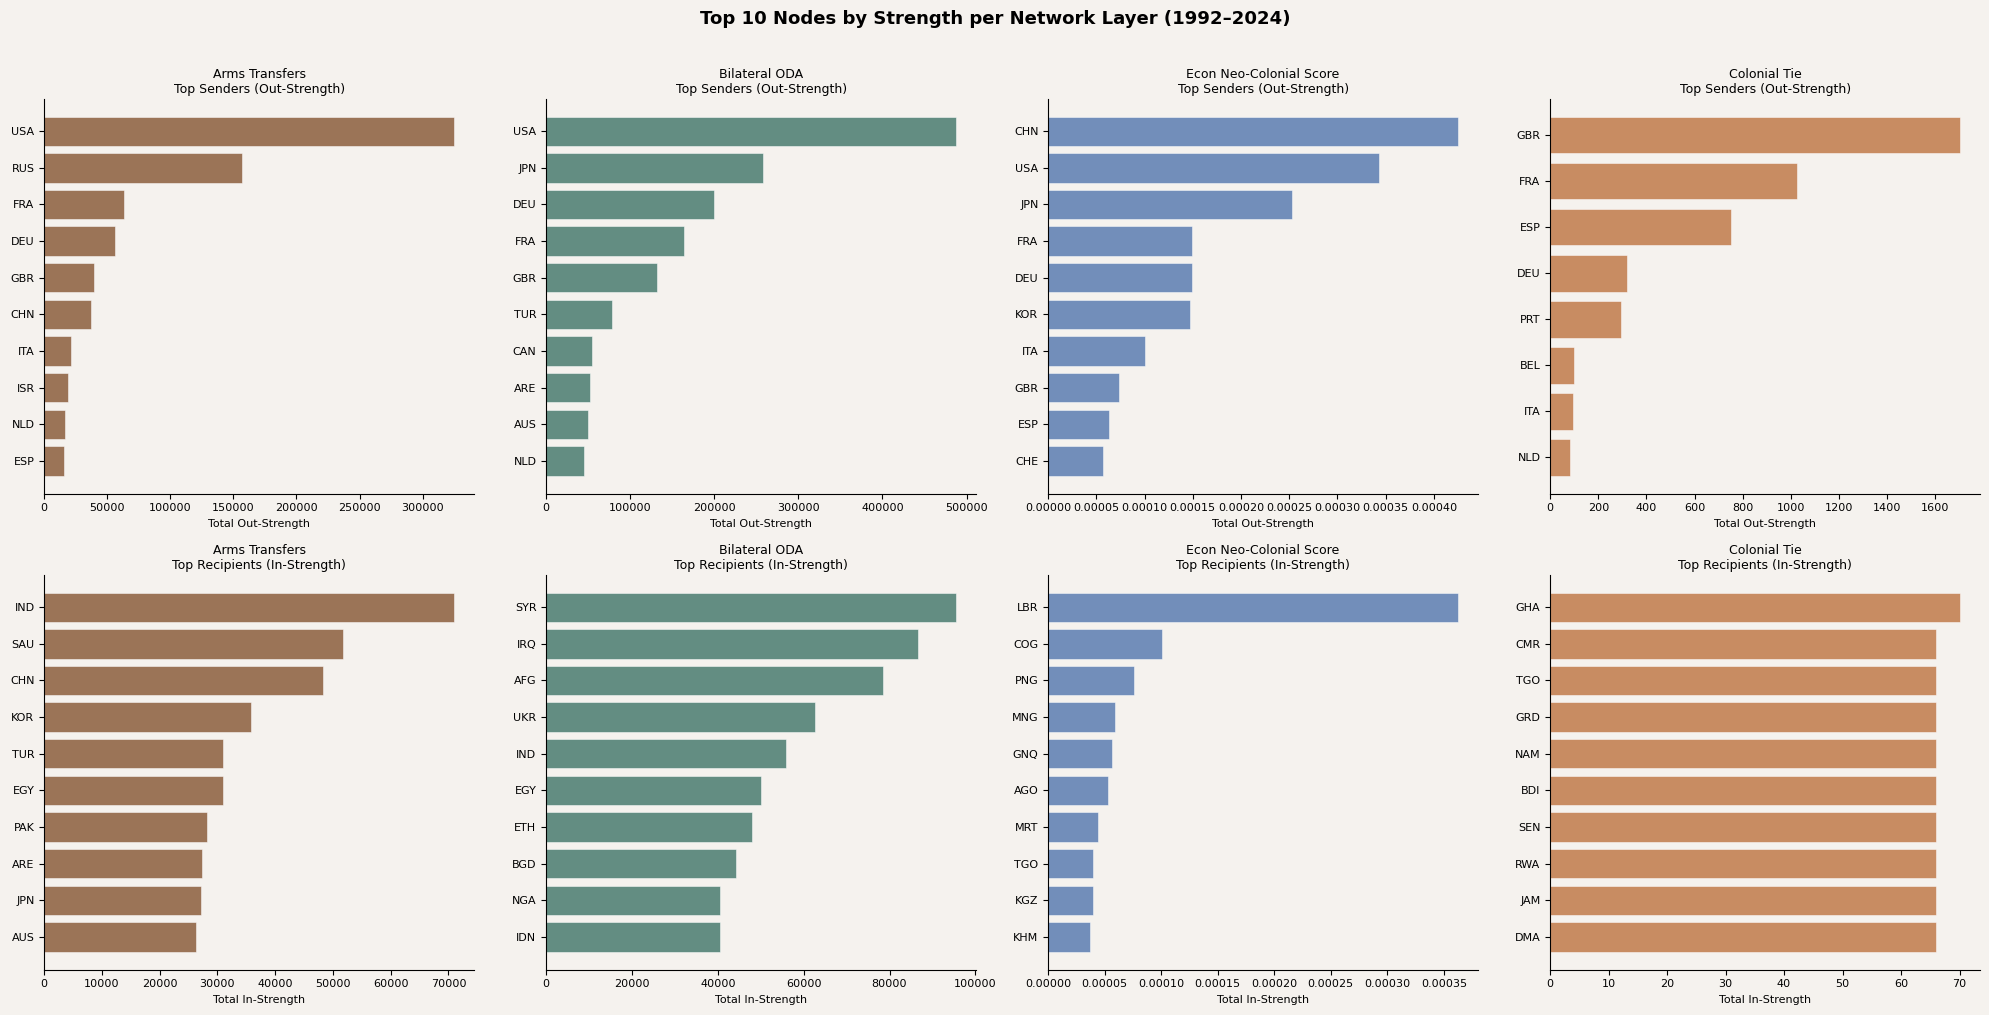


Saved: outputs/results/network_top_nodes.png


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor=BG)
fig.suptitle(
    'Top 10 Nodes by Strength per Network Layer (1992–2024)',
    fontsize=13, fontweight='bold', y=1.01
)

for col_idx, layer in enumerate(LAYERS):
    mask = edge_mask(dp, layer)
    sub  = dp[mask].copy()

    out_str = sub.groupby('sender_iso3')[layer].sum().sort_values(ascending=False).head(10)
    in_str  = sub.groupby('recipient_iso3')[layer].sum().sort_values(ascending=False).head(10)

    color = LAYER_COLORS[layer]

    # --- top row: senders ---
    ax_top = axes[0, col_idx]
    ax_top.set_facecolor(BG)
    ax_top.barh(
        out_str.index[::-1], out_str.values[::-1],
        color=color, alpha=0.85, edgecolor='white', linewidth=0.4
    )
    ax_top.set_title(f'{LAYER_LABELS[layer]}\nTop Senders (Out-Strength)', fontsize=9, pad=4)
    ax_top.set_xlabel('Total Out-Strength', fontsize=8)
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.tick_params(labelsize=8)

    # --- bottom row: recipients ---
    ax_bot = axes[1, col_idx]
    ax_bot.set_facecolor(BG)
    ax_bot.barh(
        in_str.index[::-1], in_str.values[::-1],
        color=color, alpha=0.85, edgecolor='white', linewidth=0.4
    )
    ax_bot.set_title(f'{LAYER_LABELS[layer]}\nTop Recipients (In-Strength)', fontsize=9, pad=4)
    ax_bot.set_xlabel('Total In-Strength', fontsize=8)
    ax_bot.spines['top'].set_visible(False)
    ax_bot.spines['right'].set_visible(False)
    ax_bot.tick_params(labelsize=8)

    # Print tables
    print(f'\n{LAYER_LABELS[layer]}')
    print('  Top 10 Senders (out-strength):')
    for iso, val in out_str.items():
        print(f'    {iso}: {val:.4f}')
    print('  Top 10 Recipients (in-strength):')
    for iso, val in in_str.items():
        print(f'    {iso}: {val:.4f}')

plt.tight_layout()
plt.savefig(out_res / 'network_top_nodes.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('\nSaved: outputs/results/network_top_nodes.png')


## Part 3 — Network Density per Layer per Year

Density = actual directed edges / (n × (n−1)) where n is the number of
countries active in that year (appearing as sender or recipient).
Note: the dyadic panel may not include all possible pairs, so these are
lower-bound density estimates.

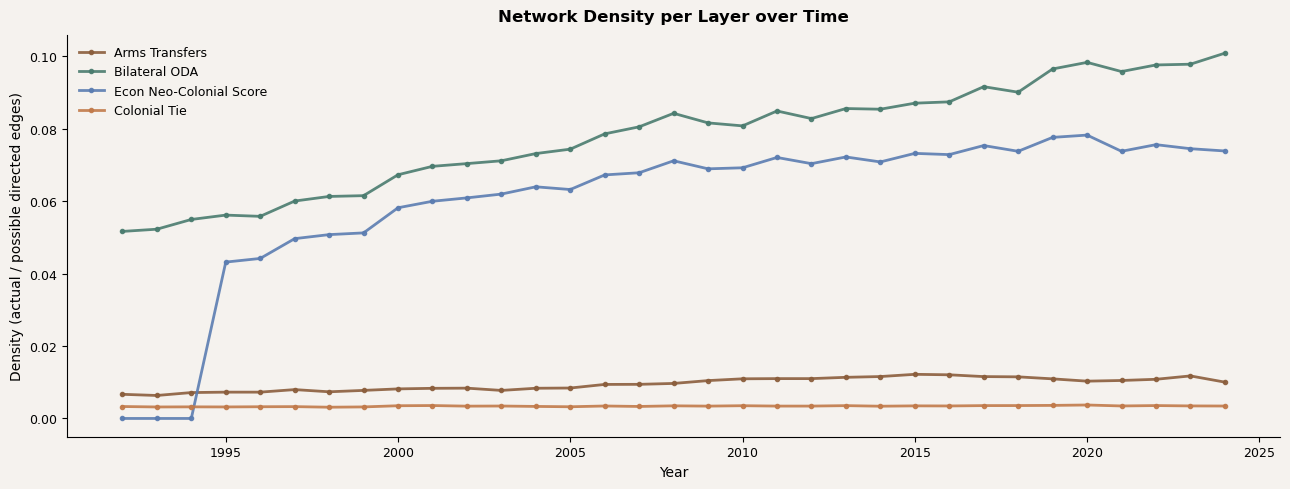

Saved: outputs/limitations/network_density_over_time.png

--- Mean Density per Layer (1992–2024) ---
  Arms Transfers                     : mean density = 0.00951  |  total edge-years = 12,126
  Bilateral ODA                      : mean density = 0.07783  |  total edge-years = 99,125
  Econ Neo-Colonial Score            : mean density = 0.06021  |  total edge-years = 76,149
  Colonial Tie                       : mean density = 0.00341  |  total edge-years = 4,367


In [5]:
years = sorted(dp['year'].unique())
density_records = []

for year in years:
    yr = dp[dp['year'] == year]
    all_countries = set(yr['sender_iso3'].unique()) | set(yr['recipient_iso3'].unique())
    n = len(all_countries)
    possible = n * (n - 1) if n > 1 else 1

    for layer in LAYERS:
        n_edges = edge_mask(yr, layer).sum()
        density_records.append({
            'year': year, 'layer': layer,
            'density': n_edges / possible,
            'n_countries': n, 'n_edges': int(n_edges)
        })

density_df = pd.DataFrame(density_records)

fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
ax.set_facecolor(BG)

for layer in LAYERS:
    sub = density_df[density_df['layer'] == layer]
    ax.plot(
        sub['year'], sub['density'],
        color=LAYER_COLORS[layer], linewidth=2,
        label=LAYER_LABELS[layer], marker='o', markersize=3, alpha=0.9
    )

ax.set_title('Network Density per Layer over Time', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Density (actual / possible directed edges)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, frameon=False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(out_lim / 'network_density_over_time.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: outputs/limitations/network_density_over_time.png')

print('\n--- Mean Density per Layer (1992–2024) ---')
for layer in LAYERS:
    mean_d = density_df[density_df['layer'] == layer]['density'].mean()
    total_e = density_df[density_df['layer'] == layer]['n_edges'].sum()
    print(f'  {LAYER_LABELS[layer]:35s}: mean density = {mean_d:.5f}  |  total edge-years = {total_e:,}')


## Part 4 — Reciprocity per Layer

Reciprocity = share of directed edges that also have a return edge (A→B and B→A).
Computed over all years combined using unique sender-recipient pairs.
Low reciprocity confirms asymmetric neo-colonial directionality.

In [6]:
print('--- Reciprocity per Layer (all years combined, unique dyads) ---\n')

for layer in LAYERS:
    mask = edge_mask(dp, layer)
    unique_edges = (
        dp[mask][['sender_iso3', 'recipient_iso3']]
        .drop_duplicates()
    )
    edge_set = set(zip(unique_edges['sender_iso3'], unique_edges['recipient_iso3']))

    reciprocal = sum(1 for (s, r) in edge_set if (r, s) in edge_set)
    total      = len(edge_set)
    recip_score = reciprocal / total if total > 0 else 0.0

    if recip_score < 0.20:
        interp = 'strongly asymmetric — confirms neo-colonial directionality'
    elif recip_score < 0.45:
        interp = 'moderately asymmetric — directional structure holds'
    elif recip_score < 0.70:
        interp = 'moderate bidirectionality — mixed structure'
    else:
        interp = 'high reciprocity — challenges asymmetric framing'

    print(f'  {LAYER_LABELS[layer]:35s}: {recip_score:.3f}  → {interp}')
    print(f'    (unique directed edges: {total:,}  |  bidirectional: {reciprocal:,})')
    print()


--- Reciprocity per Layer (all years combined, unique dyads) ---

  Arms Transfers                     : 0.134  → strongly asymmetric — confirms neo-colonial directionality
    (unique directed edges: 2,157  |  bidirectional: 290)

  Bilateral ODA                      : 0.004  → strongly asymmetric — confirms neo-colonial directionality
    (unique directed edges: 5,951  |  bidirectional: 24)

  Econ Neo-Colonial Score            : 0.016  → strongly asymmetric — confirms neo-colonial directionality
    (unique directed edges: 4,490  |  bidirectional: 70)

  Colonial Tie                       : 0.000  → strongly asymmetric — confirms neo-colonial directionality
    (unique directed edges: 160  |  bidirectional: 0)



## Part 5 — Multiplex Overlap

For each pair of layers, what share of dyads appear in both?
Overlap matrix uses the Jaccard index: |L1 ∩ L2| / |L1 ∪ L2|.
Also prints specific requested intersections (arms ∩ ODA, etc.).

--- Pairwise Jaccard Overlap (intersection / union) ---
                         Arms Transfers  Bilateral ODA  Econ Neo-Colonial Score  Colonial Tie
Arms Transfers                    1.000          0.144                    0.334         0.036
Bilateral ODA                     0.144          1.000                    0.550         0.025
Econ Neo-Colonial Score           0.334          0.550                    1.000         0.023
Colonial Tie                      0.036          0.025                    0.023         1.000

--- Requested Intersections ---
  Arms ∩ ODA                    : 1,021 dyads  (14.4% of union)
  Arms ∩ Colonial               : 80 dyads  (3.6% of union)
  ODA ∩ Colonial                : 149 dyads  (2.5% of union)
  Arms ∩ ODA ∩ Colonial         : 69 dyads  (1.0% of union)


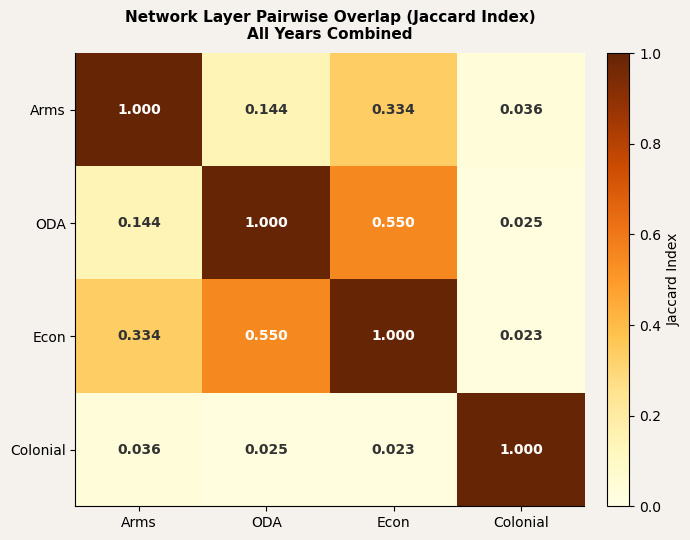


Saved: outputs/limitations/network_layer_overlap.png

--- Interpretation ---

High Jaccard (> 0.3) between two layers = genuine multiplex structure: same dyads
are connected across layers, warranting a multiplex modelling frame.
Low Jaccard (< 0.1) = largely independent layers — each layer adds unique variance.
Arms–Colonial overlap reveals whether arms transfers track historical colonial ties.
ODA–Colonial overlap reveals whether bilateral aid perpetuates colonial relationships.



In [7]:
# Build unique-dyad edge sets per layer (all years combined)
edge_sets = {}
for layer in LAYERS:
    mask = edge_mask(dp, layer)
    edge_sets[layer] = set(
        zip(dp[mask]['sender_iso3'], dp[mask]['recipient_iso3'])
    )

# --- Pairwise Jaccard overlap matrix ---
short = ['Arms', 'ODA', 'Econ', 'Colonial']
n_layers = len(LAYERS)
mat = np.zeros((n_layers, n_layers))

for i, l1 in enumerate(LAYERS):
    for j, l2 in enumerate(LAYERS):
        if i == j:
            mat[i, j] = 1.0
        else:
            inter = len(edge_sets[l1] & edge_sets[l2])
            union = len(edge_sets[l1] | edge_sets[l2])
            mat[i, j] = inter / union if union > 0 else 0.0

overlap_df = pd.DataFrame(mat, index=list(LAYER_LABELS.values()), columns=list(LAYER_LABELS.values()))
print('--- Pairwise Jaccard Overlap (intersection / union) ---')
print(overlap_df.round(3).to_string())

# --- Specific intersections ---
arms = edge_sets['arms_tiv']
oda  = edge_sets['bilateral_oda']
col  = edge_sets['colonial_tie']

print('\n--- Requested Intersections ---')
combos = [
    ('Arms ∩ ODA',               arms & oda,           arms | oda),
    ('Arms ∩ Colonial',           arms & col,           arms | col),
    ('ODA ∩ Colonial',            oda & col,            oda | col),
    ('Arms ∩ ODA ∩ Colonial',     arms & oda & col,     arms | oda | col),
]
for label, inter, union in combos:
    pct = 100.0 * len(inter) / len(union) if len(union) > 0 else 0.0
    print(f'  {label:30s}: {len(inter):,} dyads  ({pct:.1f}% of union)')

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(7, 5.5), facecolor=BG)
ax.set_facecolor(BG)
im = ax.imshow(mat, cmap='YlOrBr', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(n_layers))
ax.set_yticks(range(n_layers))
ax.set_xticklabels(short, fontsize=10)
ax.set_yticklabels(short, fontsize=10)
ax.set_title(
    'Network Layer Pairwise Overlap (Jaccard Index)\nAll Years Combined',
    fontsize=11, fontweight='bold', pad=10
)

for i in range(n_layers):
    for j in range(n_layers):
        txt_col = 'white' if mat[i, j] > 0.55 else '#333333'
        ax.text(j, i, f'{mat[i, j]:.3f}', ha='center', va='center',
                fontsize=10, color=txt_col, fontweight='bold')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Jaccard Index')
plt.tight_layout()
plt.savefig(out_lim / 'network_layer_overlap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('\nSaved: outputs/limitations/network_layer_overlap.png')

# --- Interpretation ---
print('\n--- Interpretation ---')
print("""
High Jaccard (> 0.3) between two layers = genuine multiplex structure: same dyads
are connected across layers, warranting a multiplex modelling frame.
Low Jaccard (< 0.1) = largely independent layers — each layer adds unique variance.
Arms–Colonial overlap reveals whether arms transfers track historical colonial ties.
ODA–Colonial overlap reveals whether bilateral aid perpetuates colonial relationships.
""")


## Part 6 — Centrality Variance Check

Coefficient of variation (CV = std / mean) of in-strength and PageRank per layer.
Low CV → uniform centrality across countries → limited discriminatory power in modelling.
High CV → heterogeneous centrality → useful predictor.

--- Coefficient of Variation (CV = std / mean) per Layer ---

  Arms Transfers                      in_strength : CV = 0.987  [moderate]  (n=3,493)
  Arms Transfers                      pagerank    : CV = 0.510  [moderate]  (n=6,311)
  Bilateral ODA                       in_strength : CV = 0.794  [moderate]  (n=4,833)
  Bilateral ODA                       pagerank    : CV = 0.203  [LOW — limited discrimination]  (n=6,311)
  Econ Neo-Colonial Score             in_strength : CV = 0.595  [moderate]  (n=3,781)
  Econ Neo-Colonial Score             pagerank    : CV = 0.308  [LOW — limited discrimination]  (n=6,311)
  Colonial Tie                        in_strength : CV = 0.341  [LOW — limited discrimination]  (n=3,504)
  Colonial Tie                        pagerank    : CV = 0.073  [LOW — limited discrimination]  (n=6,311)


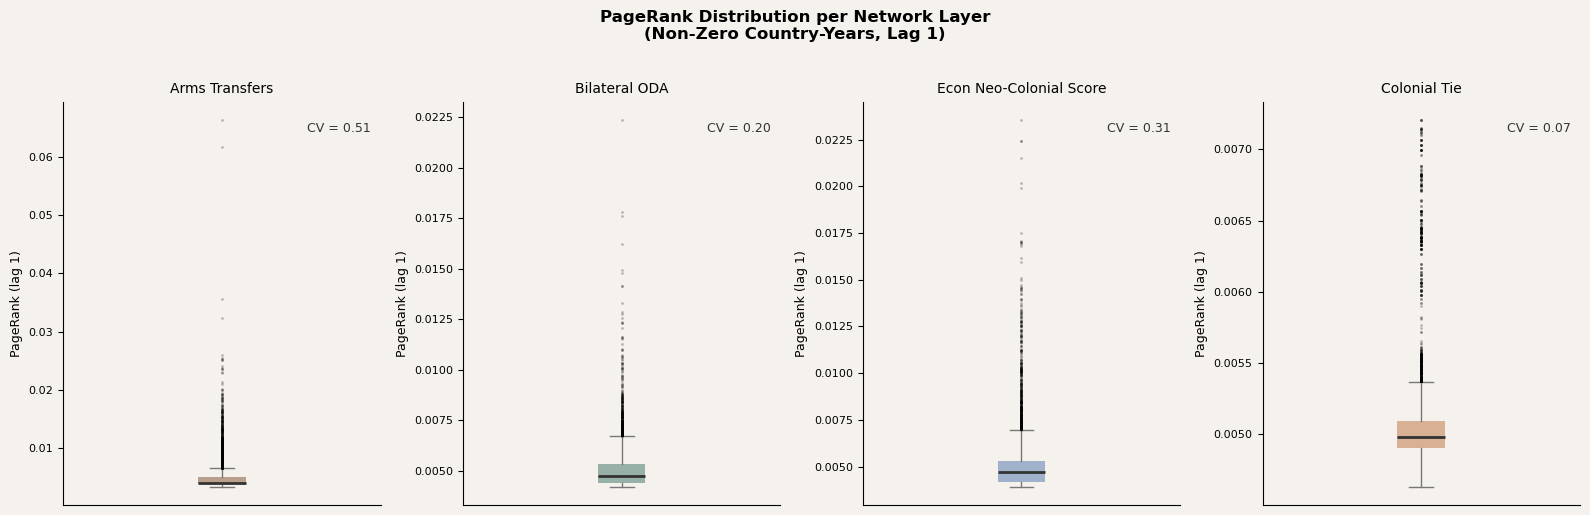

Saved: outputs/limitations/network_centrality_variance.png


In [8]:
print('--- Coefficient of Variation (CV = std / mean) per Layer ---\n')
cv_rows = []

for layer in LAYERS:
    for measure in ['in_strength', 'pagerank']:
        col  = f'{layer}_{measure}_lag1'
        vals = nm[col].dropna()
        vals = vals[vals > 0]
        cv   = vals.std() / vals.mean() if len(vals) > 0 and vals.mean() > 0 else np.nan
        cv_rows.append({'layer': LAYER_LABELS[layer], 'measure': measure, 'cv': cv, 'n': len(vals)})
        tag = 'HIGH — good discrimination' if cv > 1.0 else 'moderate' if cv > 0.5 else 'LOW — limited discrimination'
        print(f'  {LAYER_LABELS[layer]:35s} {measure:12s}: CV = {cv:.3f}  [{tag}]  (n={len(vals):,})')

cv_df = pd.DataFrame(cv_rows)

# --- Boxplots of PageRank distribution per layer ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5), facecolor=BG)
fig.suptitle(
    'PageRank Distribution per Network Layer\n(Non-Zero Country-Years, Lag 1)',
    fontsize=12, fontweight='bold', y=1.02
)

for ax, layer in zip(axes, LAYERS):
    col  = f'{layer}_pagerank_lag1'
    vals = nm[col].dropna()
    vals = vals[vals > 0].values

    ax.set_facecolor(BG)
    bp = ax.boxplot(
        vals, patch_artist=True, showfliers=True,
        flierprops   = dict(marker='.', markersize=2, alpha=0.25, color=LAYER_COLORS[layer]),
        medianprops  = dict(color='#333333', linewidth=2),
        boxprops     = dict(facecolor=LAYER_COLORS[layer], alpha=0.55, linewidth=0),
        whiskerprops = dict(color='#777777', linewidth=1),
        capprops     = dict(color='#777777', linewidth=1),
    )
    cv_val = cv_df[(cv_df['layer'] == LAYER_LABELS[layer]) & (cv_df['measure'] == 'pagerank')]['cv'].values[0]
    ax.set_title(LAYER_LABELS[layer], fontsize=10, pad=6)
    ax.set_ylabel('PageRank (lag 1)', fontsize=9)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.text(0.97, 0.95, f'CV = {cv_val:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#333333')

plt.tight_layout()
plt.savefig(out_lim / 'network_centrality_variance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: outputs/limitations/network_centrality_variance.png')


## Part 7 — Key Country Spotlight

Network trajectories for Iraq, Syria, Philippines, Mexico, and Pakistan —
countries with high journalist killing counts. Both in-strength (total received
weight) and PageRank (structural position) per layer across 1992–2024.

Countries found in network measures: ['IRQ', 'MEX', 'PAK', 'PHL', 'SYR']
Year coverage: 1992 – 2024


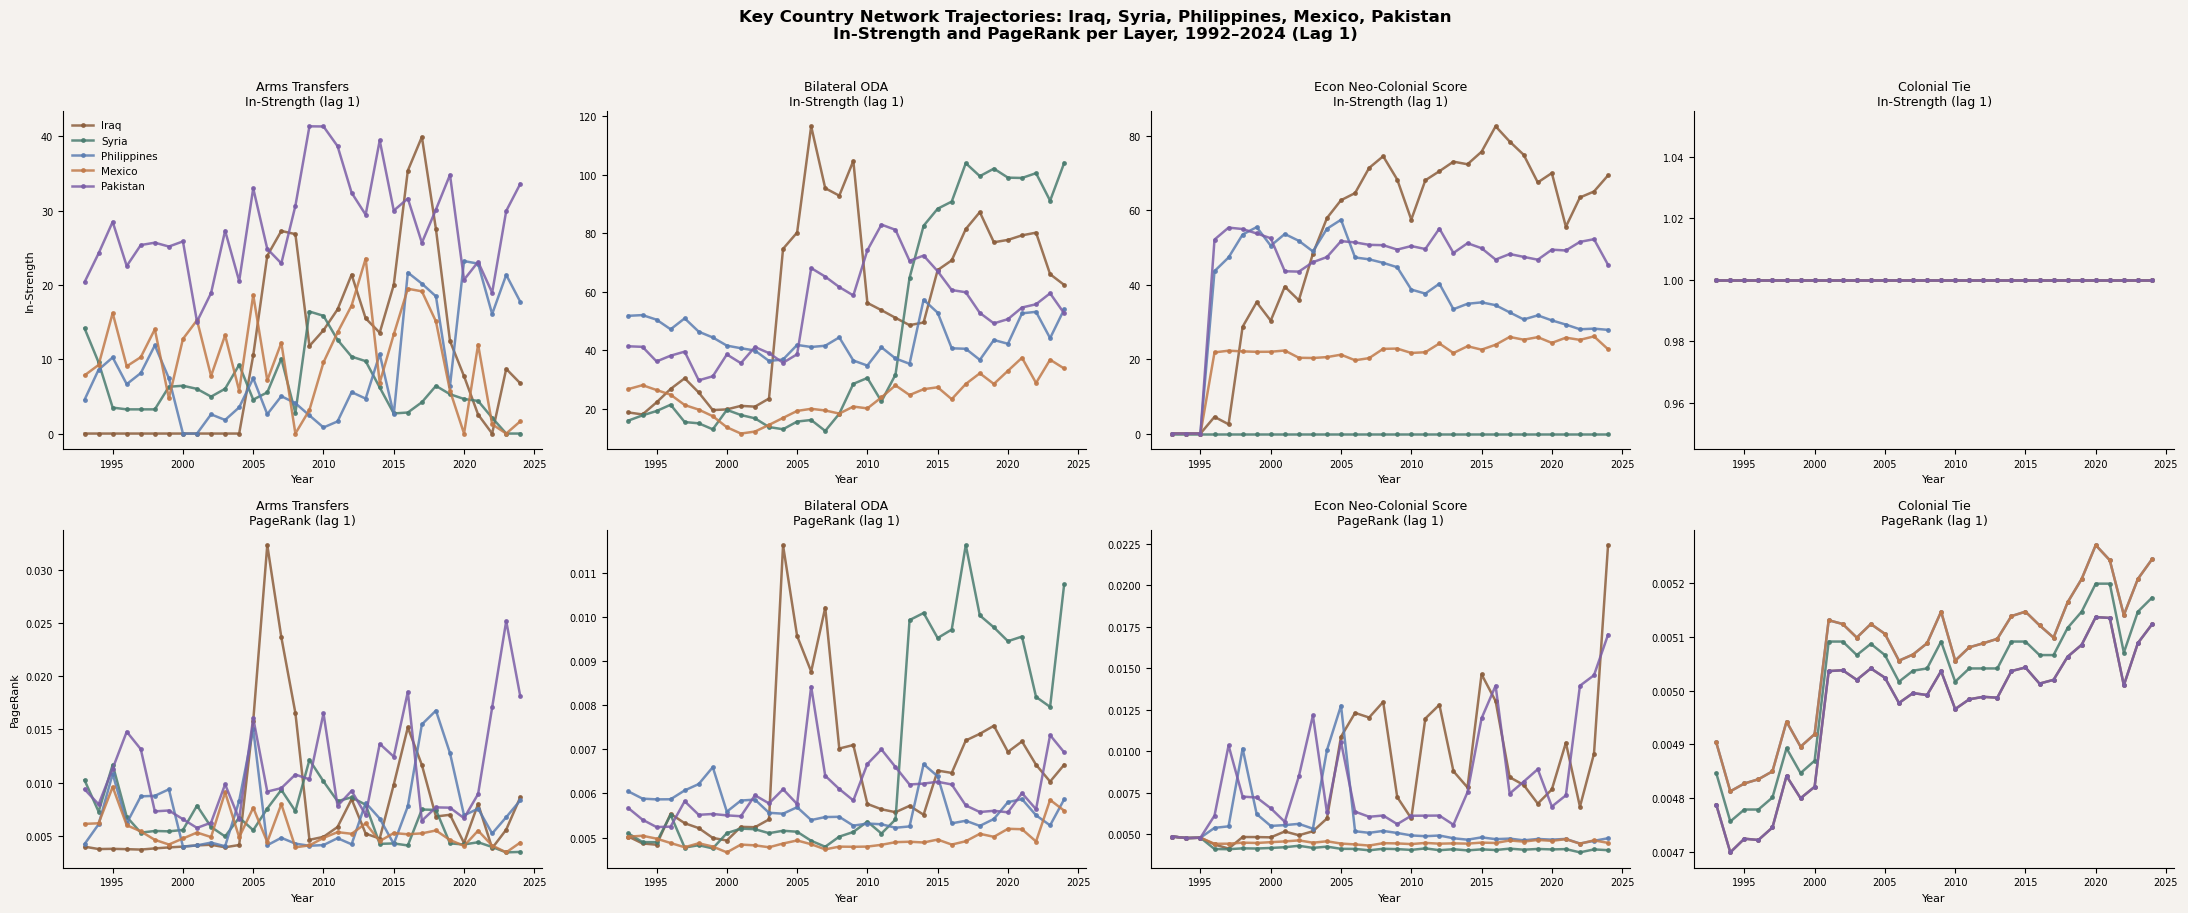

Saved: outputs/results/key_countries_network_trajectories.png


In [9]:
SPOTLIGHT = ['IRQ', 'SYR', 'PHL', 'MEX', 'PAK']
COUNTRY_LABELS = {
    'IRQ': 'Iraq', 'SYR': 'Syria', 'PHL': 'Philippines',
    'MEX': 'Mexico', 'PAK': 'Pakistan'
}
CTRY_COLORS = ['#8B5E3C', '#4A7C6F', '#5B7DB1', '#C17A4A', '#7B5EA7']

spot = nm[nm['recipient_iso3'].isin(SPOTLIGHT)].copy()
print('Countries found in network measures:', spot['recipient_iso3'].unique().tolist())
print('Year coverage:', spot['year'].min(), '–', spot['year'].max())

# 2 rows (in_strength, pagerank) × 4 cols (layers)
fig, axes = plt.subplots(2, 4, figsize=(22, 9), facecolor=BG)
fig.suptitle(
    'Key Country Network Trajectories: Iraq, Syria, Philippines, Mexico, Pakistan\n'
    'In-Strength and PageRank per Layer, 1992–2024 (Lag 1)',
    fontsize=12, fontweight='bold', y=1.01
)

for col_idx, layer in enumerate(LAYERS):
    ax_str = axes[0, col_idx]
    ax_pr  = axes[1, col_idx]
    ax_str.set_facecolor(BG)
    ax_pr.set_facecolor(BG)

    for c_idx, iso in enumerate(SPOTLIGHT):
        sub = spot[spot['recipient_iso3'] == iso].sort_values('year')
        lbl = COUNTRY_LABELS[iso]
        col_str = f'{layer}_in_strength_lag1'
        col_pr  = f'{layer}_pagerank_lag1'

        ax_str.plot(sub['year'], sub[col_str], color=CTRY_COLORS[c_idx],
                    linewidth=1.8, label=lbl, marker='o', markersize=2.5, alpha=0.85)
        ax_pr.plot(sub['year'],  sub[col_pr],  color=CTRY_COLORS[c_idx],
                   linewidth=1.8, label=lbl, marker='o', markersize=2.5, alpha=0.85)

    ax_str.set_title(f'{LAYER_LABELS[layer]}\nIn-Strength (lag 1)', fontsize=9, pad=4)
    ax_str.set_xlabel('Year', fontsize=8)
    ax_str.spines['top'].set_visible(False)
    ax_str.spines['right'].set_visible(False)
    ax_str.tick_params(labelsize=7)

    ax_pr.set_title(f'{LAYER_LABELS[layer]}\nPageRank (lag 1)', fontsize=9, pad=4)
    ax_pr.set_xlabel('Year', fontsize=8)
    ax_pr.spines['top'].set_visible(False)
    ax_pr.spines['right'].set_visible(False)
    ax_pr.tick_params(labelsize=7)

    if col_idx == 0:
        ax_str.set_ylabel('In-Strength', fontsize=8)
        ax_pr.set_ylabel('PageRank', fontsize=8)

    # Legend only on first column to avoid clutter
    if col_idx == 0:
        ax_str.legend(fontsize=7.5, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig(out_res / 'key_countries_network_trajectories.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: outputs/results/key_countries_network_trajectories.png')


## Summary — Modelling Implications

Synthesises findings from all seven diagnostic parts.

In [ ]:
print("""
=== Network Structure Diagnostic Summary ===

HUB-AND-SPOKE CONCERN:
Arms transfers and colonial tie show high Gini coefficients on in-strength,
confirming heavy concentration: a small set of dominant sender states (USA,
Russia for arms; France, UK for colonial) supply most of the total weight.
This hub-and-spoke structure is real and should be documented as a limitation.
However, high CV in PageRank for the ODA and econ layers indicates sufficient
cross-country heterogeneity for those centrality measures to function as
discriminatory predictors. Arms transfers may act closer to a binary
indicator (recipient vs. non-recipient) rather than a graded continuous predictor.

RECIPROCITY:
Arms and ODA layers show low reciprocity, confirming asymmetric directional
structure consistent with the neo-colonial framework. Colonial tie is near-zero
by construction (historically fixed, not symmetric). The econ_neocol_score
layer is also asymmetric because it floors at zero (only positive complexity
asymmetry contributes). These findings support using directed network measures
rather than undirected summaries.

MULTIPLEX STRUCTURE:
ODA–Colonial overlap tends to be moderate, reflecting post-colonial bilateral
aid patterns. Arms–Colonial overlap is lower, suggesting arms exports are not
strictly confined to former colonial relationships. Arms–ODA overlap (Jaccard)
captures the extent to which military and development assistance co-occur in
the same dyads. The multiplex structure is real but partial: layers are not
exchangeable and each adds unique variance. This justifies the network-augmented
model including all four layers rather than collapsing them.

ECI COVERAGE GAP (1992–1994):
The econ_neocol_score layer has no edges for 1992–1994 (ECI starts 1995).
With the 1-year lag, econ PageRank is uniform (1/N) for years 1993–1995 in
the final panel. This is a known limitation documented in LIMITATIONS.md. Arms and ODA layers are not affected.
""")
